# did_multiplegt_dyn - Wagepan Test Suite

This notebook runs comprehensive tests on the wagepan dataset to verify
that the Python implementation matches the Stata results.

## Test Configuration (matching Stata dofile)
- Dataset: wagepan.dta
- Outcome: lwage (log wage)
- Group: nr (individual ID)
- Time: year
- Treatment: union (union membership)
- Effects: 5
- Placebos: 2
- Bootstrap: 20 reps, seed 1234
- by_var: black
- het_var: black

In [24]:
import pandas as pd
import polars as pl
import numpy as np
import time
import warnings
from pathlib import Path

# Import the package
import sys
sys.path.insert(0, str(Path('..').resolve().parent / 'src'))
from did_multiplegt_dyn import DidMultiplegtDyn

In [2]:
# Load data
data_path = Path('../data/wagepan.dta')
df_pd = pd.read_stata(data_path)
df = pl.from_pandas(df_pd)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 4360 rows, 27 columns


nr,year,black,exper,hisp,hours,married,occ1,occ2,occ3,occ4,occ5,occ6,occ7,occ8,occ9,educ,union,lwage,d81,d82,d83,d84,d85,d86,d87,expersq
f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
13.0,1980.0,0.0,1.0,0.0,2672.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,14.0,0.0,1.19754,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
13.0,1981.0,0.0,2.0,0.0,2320.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,14.0,1.0,1.85306,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
13.0,1982.0,0.0,3.0,0.0,2940.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,14.0,0.0,1.344462,0.0,1.0,0.0,0.0,0.0,0.0,0.0,9.0
13.0,1983.0,0.0,4.0,0.0,2960.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,14.0,0.0,1.433213,0.0,0.0,1.0,0.0,0.0,0.0,0.0,16.0
13.0,1984.0,0.0,5.0,0.0,3071.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,14.0,0.0,1.568125,0.0,0.0,0.0,1.0,0.0,0.0,0.0,25.0


In [3]:
# Base configuration (matching Stata locals)
BASE_CONFIG = {
    'outcome': 'lwage',     # local y
    'group': 'nr',          # local g
    'time': 'year',         # local t
    'treatment': 'union',   # local d
    'effects': 5,           # local n_eff
    'placebo': 2            # local n_pl
}

# Additional Stata locals
BOOTSTRAP_REPS = 20         # local b_reps
BOOTSTRAP_SEED = 1234       # local b_seed
CONTROLS = ['hours']        # local cont
TRENDS_NONPARAM = ['black'] # local nonparam
WEIGHT_VAR = 'educ'         # local wght
CLUSTER_VAR = 'hisp'        # local clust
BY_VAR = 'black'            # local by_var
HET_VAR = 'black'           # local het_var

In [4]:
# Test models (matching Stata dofile order)
TEST_MODELS = {
    'Baseline': {},
    'Placebos': {},
    'Normalized': {'normalized': True},
    'Controls': {'controls': CONTROLS},
    'Trends_Nonparam': {'trends_nonparam': TRENDS_NONPARAM},
    'Trends_Lin': {'trends_lin': True},
    'Continuous': {'continuous': 1},
    'Weight': {'weight': WEIGHT_VAR},
    'Cluster': {'cluster': CLUSTER_VAR},
    'Same_Switchers': {'same_switchers': True},
    'Same_Switchers_Placebo': {'same_switchers': True, 'same_switchers_pl': True},
    'Switchers_In': {'switchers': 'in'},
    'Switchers_Out': {'switchers': 'out'},
    'Only_Never_Switchers': {'only_never_switchers': True},
    'CI_Level_90': {'ci_level': 90},
    'CI_Level_99': {'ci_level': 99},
    'Less_Conservative_SE': {'less_conservative_se': True},
    'Bootstrap': {'bootstrap': (BOOTSTRAP_REPS, BOOTSTRAP_SEED)},
    'Dont_Drop_Larger_Lower': {'dont_drop_larger_lower': True},
    'Effects_Equal': {'effects_equal': True},
}

In [5]:
def run_test(df, model_name, model_config, base_config):
    """
    Run a single test and extract results.
    
    Returns:
        dict: Results with runtime and coefficients
    """
    config = base_config.copy()
    config.update(model_config)
    
    results = []
    runtime = None
    error = None
    
    try:
        start_time = time.time()
        
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            model = DidMultiplegtDyn(df=df, **config)
            result = model.fit()
        
        runtime = time.time() - start_time
        
        # Extract effects
        dyn = result.result['did_multiplegt_dyn']
        effects_df = dyn.get('Effects')
        if effects_df is not None:
            for i, row in effects_df.iterrows():
                idx = int(i.replace('Effect_', '')) if isinstance(i, str) else i + 1
                results.append({
                    'Example': 'Wagepan',
                    'Model': model_name,
                    'Type': 'Effect',
                    'Index': idx,
                    'Estimate': row['Estimate'],
                    'SE': row['SE']
                })
        
        # Extract placebos
        placebos_df = dyn.get('Placebos')
        if placebos_df is not None:
            for i, row in placebos_df.iterrows():
                idx = int(i.replace('Placebo_', '')) if isinstance(i, str) else i + 1
                results.append({
                    'Example': 'Wagepan',
                    'Model': model_name,
                    'Type': 'Placebo',
                    'Index': idx,
                    'Estimate': row['Estimate'],
                    'SE': row['SE']
                })
        
        # Extract average effect
        ate_df = dyn.get('ATE')
        if ate_df is not None and len(ate_df) > 0:
            results.append({
                'Example': 'Wagepan',
                'Model': model_name,
                'Type': 'Avg_Effect',
                'Index': 0,
                'Estimate': ate_df.iloc[0]['Estimate'],
                'SE': ate_df.iloc[0]['SE']
            })
            
    except Exception as e:
        error = str(e)
        print(f"  ERROR: {error[:100]}")
    
    return {
        'model': model_name,
        'runtime': runtime,
        'results': results,
        'error': error
    }

In [6]:
# Run all tests
all_results = []
runtime_records = []

for model_name, model_config in TEST_MODELS.items():
    print(f"Running: {model_name}...", end=' ')
    
    output = run_test(df, model_name, model_config, BASE_CONFIG)
    
    if output['error']:
        print(f"FAILED")
    else:
        print(f"OK ({output['runtime']:.2f}s)")
        all_results.extend(output['results'])
        runtime_records.append({
            'Example': 'Wagepan',
            'Model': model_name,
            'Runtime_sec': output['runtime'],
            'Platform': 'Python'
        })

Running: Baseline... OK (0.47s)
Running: Placebos... OK (0.45s)
Running: Normalized... OK (0.48s)
Running: Controls... OK (0.85s)
Running: Trends_Nonparam... OK (0.45s)
Running: Trends_Lin... OK (1.72s)
Running: Continuous... OK (1.63s)
Running: Weight... OK (0.46s)
Running: Cluster... OK (0.54s)
Running: Same_Switchers... OK (0.67s)
Running: Same_Switchers_Placebo... OK (0.75s)
Running: Switchers_In... OK (0.22s)
Running: Switchers_Out... OK (0.22s)
Running: Only_Never_Switchers... OK (0.45s)
Running: CI_Level_90... OK (0.46s)
Running: CI_Level_99... OK (0.46s)
Running: Less_Conservative_SE... OK (0.47s)
Running: Bootstrap... OK (0.46s)
Running: Dont_Drop_Larger_Lower... OK (0.45s)
Running: Effects_Equal... OK (0.45s)


In [7]:
# Create results DataFrames
coefficients_df = pd.DataFrame(all_results)
runtime_df = pd.DataFrame(runtime_records)

print(f"\n=== Results Summary ===")
print(f"Total coefficients extracted: {len(coefficients_df)}")
print(f"Models run successfully: {len(runtime_df)}")


=== Results Summary ===
Total coefficients extracted: 160
Models run successfully: 20


In [8]:
# Display coefficients summary
print("\n=== Coefficients Preview ===")
coefficients_df.head(20)


=== Coefficients Preview ===


,Example,Model,Type,Index,Estimate,SE
0,Wagepan,Baseline,Effect,1,0.040951,0.033971
1,Wagepan,Baseline,Effect,2,0.021888,0.039339
2,Wagepan,Baseline,Effect,3,0.031102,0.042598
3,Wagepan,Baseline,Effect,4,0.018163,0.047210
4,Wagepan,Baseline,Effect,5,-0.049966,0.054625
5,Wagepan,Baseline,Placebo,1,-0.088395,0.042258
6,Wagepan,Baseline,Placebo,2,0.037091,0.058104
7,Wagepan,Baseline,Avg_Effect,0,0.023519,0.055166
8,Wagepan,Placebos,Effect,1,0.040951,0.033971
9,Wagepan,Placebos,Effect,2,0.021888,0.039339


In [9]:
# Display runtime summary
print("\n=== Runtime Summary ===")
runtime_df


=== Runtime Summary ===


,Example,Model,Runtime_sec,Platform
0,Wagepan,Baseline,0.469422,Python
1,Wagepan,Placebos,0.446953,Python
2,Wagepan,Normalized,0.479088,Python
3,Wagepan,Controls,0.854729,Python
4,Wagepan,Trends_Nonparam,0.451621,Python
5,Wagepan,Trends_Lin,1.722528,Python
6,Wagepan,Continuous,1.629626,Python
7,Wagepan,Weight,0.458646,Python
8,Wagepan,Cluster,0.542955,Python
9,Wagepan,Same_Switchers,0.667598,Python


In [10]:
# Save results
output_dir = Path('../data/expected_results')
output_dir.mkdir(exist_ok=True)

coefficients_df.to_csv(output_dir / 'coefficients_Python.csv', index=False)
runtime_df.to_csv(output_dir / 'runtime_Python.csv', index=False)

print(f"Results saved to {output_dir}")

Results saved to ../data/expected_results


---
## Baseline Model - Full Output

This shows the complete output similar to Stata's display.

In [25]:
# Run baseline model with full output
model = DidMultiplegtDyn(
    df=df,
    outcome='lwage',
    group='nr',
    time='year',
    treatment='union',
    effects=5,
    placebo=2
)
result = model.fit()
model.summary()

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI      N  Switchers    N.w  Switchers.w
            Effect_1  0.040951 0.033971 -0.025631  0.107533 2767.0      246.0 2767.0        246.0
            Effect_2  0.021888 0.039339 -0.055215  0.098990 2292.0      225.0 2292.0        225.0
            Effect_3  0.031102 0.042598 -0.052388  0.114592 1885.0      212.0 1885.0        212.0
            Effect_4  0.018163 0.047210 -0.074367  0.110693 1497.0      195.0 1497.0        195.0
            Effect_5 -0.049966 0.054625 -0.157030  0.057098 1126.0      174.0 1126.0        174.0
Average_Total_Effect  0.023519 0.055166 -0.084604  0.131642 3573.0     1052.0 3573.0       1052.0
           Placebo_1 -0.088395 0.042258 -0.171219 -0.005570 2222.0      155.0 2222.0        155.0
           Placebo_2  0.037091 0.058104 -0.076790  0.150972 1376.0       74.0 1376.0         74.0
Test of joint nullity of the effects: p-value = 0.38

,Block,Estimate,SE,LB CI,UB CI,N,Switchers,N.w,Switchers.w
0,Effect_1,0.040951,0.033971,-0.025631,0.107533,2767.0,246.0,2767.0,246.0
1,Effect_2,0.021888,0.039339,-0.055215,0.098990,2292.0,225.0,2292.0,225.0
2,Effect_3,0.031102,0.042598,-0.052388,0.114592,1885.0,212.0,1885.0,212.0
3,Effect_4,0.018163,0.047210,-0.074367,0.110693,1497.0,195.0,1497.0,195.0
4,Effect_5,-0.049966,0.054625,-0.157030,0.057098,1126.0,174.0,1126.0,174.0
5,Average_Total_Effect,0.023519,0.055166,-0.084604,0.131642,3573.0,1052.0,3573.0,1052.0
6,Placebo_1,-0.088395,0.042258,-0.171219,-0.005570,2222.0,155.0,2222.0,155.0
7,Placebo_2,0.037091,0.058104,-0.076790,0.150972,1376.0,74.0,1376.0,74.0


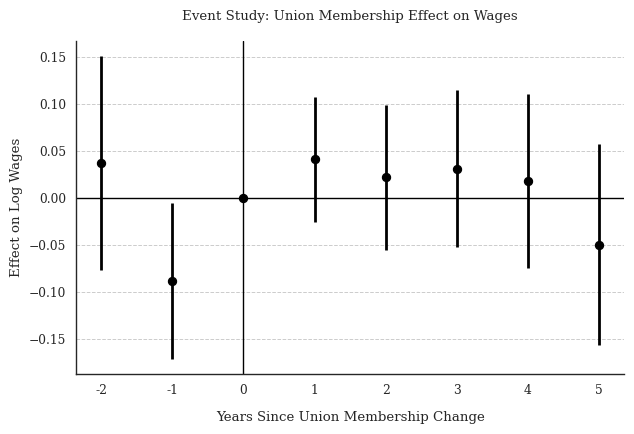

In [12]:
# Plot event study
model.plot(
    title='Event Study: Union Membership Effect on Wages',
    x_label='Years Since Union Membership Change',
    y_label='Effect on Log Wages'
)

---
## Bootstrap Example

Stata command:
```stata
did_multiplegt_dyn lwage nr year union, graph_off effects(5) placebo(2) bootstrap(20, 1234)
```

In [13]:
# Bootstrap with 20 replications and seed 1234 (matching Stata)
print("Running Bootstrap model (20 reps, seed 1234)...")
print("Note: Bootstrap requires continuous option for valid inference.")

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    model_bootstrap = DidMultiplegtDyn(
        df=df,
        outcome='lwage',
        group='nr',
        time='year',
        treatment='union',
        effects=5,
        placebo=2,
        bootstrap=(20, 1234)
    )
    result_bootstrap = model_bootstrap.fit()

model_bootstrap.summary()

Running Bootstrap model (20 reps, seed 1234)...
Note: Bootstrap requires continuous option for valid inference.
             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI      N  Switchers    N.w  Switchers.w
            Effect_1  0.040951 0.033971 -0.025631  0.107533 2767.0      246.0 2767.0        246.0
            Effect_2  0.021888 0.039339 -0.055215  0.098990 2292.0      225.0 2292.0        225.0
            Effect_3  0.031102 0.042598 -0.052388  0.114592 1885.0      212.0 1885.0        212.0
            Effect_4  0.018163 0.047210 -0.074367  0.110693 1497.0      195.0 1497.0        195.0
            Effect_5 -0.049966 0.054625 -0.157030  0.057098 1126.0      174.0 1126.0        174.0
Average_Total_Effect  0.023519 0.055166 -0.084604  0.131642 3573.0     1052.0 3573.0       1052.0
           Placebo_1 -0.088395 0.042258 -0.171219 -0.005570 2222.0      155.0 2222.0        155.0
           Placebo_2  0.037091 0.05810

,Block,Estimate,SE,LB CI,UB CI,N,Switchers,N.w,Switchers.w
0,Effect_1,0.040951,0.033971,-0.025631,0.107533,2767.0,246.0,2767.0,246.0
1,Effect_2,0.021888,0.039339,-0.055215,0.098990,2292.0,225.0,2292.0,225.0
2,Effect_3,0.031102,0.042598,-0.052388,0.114592,1885.0,212.0,1885.0,212.0
3,Effect_4,0.018163,0.047210,-0.074367,0.110693,1497.0,195.0,1497.0,195.0
4,Effect_5,-0.049966,0.054625,-0.157030,0.057098,1126.0,174.0,1126.0,174.0
5,Average_Total_Effect,0.023519,0.055166,-0.084604,0.131642,3573.0,1052.0,3573.0,1052.0
6,Placebo_1,-0.088395,0.042258,-0.171219,-0.005570,2222.0,155.0,2222.0,155.0
7,Placebo_2,0.037091,0.058104,-0.076790,0.150972,1376.0,74.0,1376.0,74.0


---
## Continuous Treatment Example

Stata command:
```stata
did_multiplegt_dyn lwage nr year union, graph_off effects(5) placebo(2) continuous(1)
```

In [14]:
# Continuous treatment
print("Running Continuous model...")

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    model_continuous = DidMultiplegtDyn(
        df=df,
        outcome='lwage',
        group='nr',
        time='year',
        treatment='union',
        effects=5,
        placebo=2,
        continuous=1
    )
    result_continuous = model_continuous.fit()

model_continuous.summary()

Running Continuous model...
             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI      N  Switchers    N.w  Switchers.w
            Effect_1  0.040951 0.033972 -0.025634  0.107535 2767.0      246.0 2767.0        246.0
            Effect_2  0.013184 0.040367 -0.065933  0.092301 2292.0      225.0 2292.0        225.0
            Effect_3  0.022833 0.043042 -0.061527  0.107193 1885.0      212.0 1885.0        212.0
            Effect_4  0.005728 0.048457 -0.089246  0.100703 1497.0      195.0 1497.0        195.0
            Effect_5 -0.057970 0.055835 -0.167406  0.051465 1126.0      174.0 1126.0        174.0
Average_Total_Effect  0.012749 0.056419 -0.097831  0.123328 3573.0     1052.0 3573.0       1052.0
           Placebo_1 -0.078758 0.038134 -0.153499 -0.004017 2222.0      155.0 2222.0        155.0
           Placebo_2  0.037396 0.051935 -0.064395  0.139188 1376.0       74.0 1376.0         74.0
Test of joint nullity of

,Block,Estimate,SE,LB CI,UB CI,N,Switchers,N.w,Switchers.w
0,Effect_1,0.040951,0.033972,-0.025634,0.107535,2767.0,246.0,2767.0,246.0
1,Effect_2,0.013184,0.040367,-0.065933,0.092301,2292.0,225.0,2292.0,225.0
2,Effect_3,0.022833,0.043042,-0.061527,0.107193,1885.0,212.0,1885.0,212.0
3,Effect_4,0.005728,0.048457,-0.089246,0.100703,1497.0,195.0,1497.0,195.0
4,Effect_5,-0.057970,0.055835,-0.167406,0.051465,1126.0,174.0,1126.0,174.0
5,Average_Total_Effect,0.012749,0.056419,-0.097831,0.123328,3573.0,1052.0,3573.0,1052.0
6,Placebo_1,-0.078758,0.038134,-0.153499,-0.004017,2222.0,155.0,2222.0,155.0
7,Placebo_2,0.037396,0.051935,-0.064395,0.139188,1376.0,74.0,1376.0,74.0


---
## Design Option Example

Shows treatment path information (similar to Stata's console output).

Stata command:
```stata
did_multiplegt_dyn lwage nr year union, graph_off effects(5) placebo(2) design(,console)
```

In [15]:
# Design option - shows treatment paths
print("Running model with design option...")
print("This displays treatment path information similar to Stata.\n")

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    model_design = DidMultiplegtDyn(
        df=df,
        outcome='lwage',
        group='nr',
        time='year',
        treatment='union',
        effects=5,
        placebo=2,
        design=(1, 'console')  # Show 90% of treatment paths
    )
    result_design = model_design.fit()

model_design.summary()

Running model with design option...
This displays treatment path information similar to Stata.


  Detection of treatment paths - 5 periods after first switch
             #Groups    %Groups  l=0  l=1  l=2  l=3  l=4  l=5
TreatPath1        38  21.839080  1.0  0.0  0.0  0.0  0.0  0.0
TreatPath2        35  20.114943  0.0  1.0  0.0  0.0  0.0  0.0
TreatPath3        23  13.218391  0.0  1.0  1.0  1.0  1.0  1.0
TreatPath4         7   4.022989  1.0  0.0  0.0  0.0  0.0  1.0
TreatPath5         7   4.022989  0.0  1.0  1.0  0.0  0.0  0.0
TreatPath6         7   4.022989  0.0  1.0  0.0  1.0  1.0  1.0
TreatPath7         6   3.448276  1.0  0.0  1.0  1.0  1.0  1.0
TreatPath8         6   3.448276  0.0  1.0  0.0  1.0  0.0  0.0
TreatPath9         4   2.298851  0.0  1.0  1.0  1.0  0.0  0.0
TreatPath10        4   2.298851  1.0  0.0  1.0  1.0  0.0  0.0
TreatPath11        4   2.298851  0.0  1.0  0.0  0.0  0.0  1.0
TreatPath12        3   1.724138  1.0  0.0  0.0  0.0  1.0  0.0
TreatPath13        3   1.724138  1.

,Block,Estimate,SE,LB CI,UB CI,N,Switchers,N.w,Switchers.w
0,Effect_1,0.040951,0.033971,-0.025631,0.107533,2767.0,246.0,2767.0,246.0
1,Effect_2,0.021888,0.039339,-0.055215,0.098990,2292.0,225.0,2292.0,225.0
2,Effect_3,0.031102,0.042598,-0.052388,0.114592,1885.0,212.0,1885.0,212.0
3,Effect_4,0.018163,0.047210,-0.074367,0.110693,1497.0,195.0,1497.0,195.0
4,Effect_5,-0.049966,0.054625,-0.157030,0.057098,1126.0,174.0,1126.0,174.0
5,Average_Total_Effect,0.023519,0.055166,-0.084604,0.131642,3573.0,1052.0,3573.0,1052.0
6,Placebo_1,-0.088395,0.042258,-0.171219,-0.005570,2222.0,155.0,2222.0,155.0
7,Placebo_2,0.037091,0.058104,-0.076790,0.150972,1376.0,74.0,1376.0,74.0


---
## Predict Het (Heterogeneous Effects) Example

Analyzes heterogeneous effects by a grouping variable.

Stata command:
```stata
did_multiplegt_dyn lwage nr year union, graph_off effects(5) placebo(2) predict_het(black, all)
```

In [16]:
# Predict het - heterogeneous effects by 'black'
print("Running model with predict_het option (het_var = black)...")
print("This analyzes heterogeneous effects similar to Stata.\n")

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    model_het = DidMultiplegtDyn(
        df=df,
        outcome='lwage',
        group='nr',
        time='year',
        treatment='union',
        effects=5,
        placebo=2,
        predict_het=['black', 'all']  # het_var = black, all effects
    )
    result_het = model_het.fit()

model_het.summary()

Running model with predict_het option (het_var = black)...
This analyzes heterogeneous effects similar to Stata.

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI      N  Switchers    N.w  Switchers.w
            Effect_1  0.040951 0.033971 -0.025631  0.107533 2767.0      246.0 2767.0        246.0
            Effect_2  0.021888 0.039339 -0.055215  0.098990 2292.0      225.0 2292.0        225.0
            Effect_3  0.031102 0.042598 -0.052388  0.114592 1885.0      212.0 1885.0        212.0
            Effect_4  0.018163 0.047210 -0.074367  0.110693 1497.0      195.0 1497.0        195.0
            Effect_5 -0.049966 0.054625 -0.157030  0.057098 1126.0      174.0 1126.0        174.0
Average_Total_Effect  0.023519 0.055166 -0.084604  0.131642 3573.0     1052.0 3573.0       1052.0
           Placebo_1 -0.088395 0.042258 -0.171219 -0.005570 2222.0      155.0 2222.0        155.0
           Placebo_2  0.037091 0.058

,Block,Estimate,SE,LB CI,UB CI,N,Switchers,N.w,Switchers.w
0,Effect_1,0.040951,0.033971,-0.025631,0.107533,2767.0,246.0,2767.0,246.0
1,Effect_2,0.021888,0.039339,-0.055215,0.098990,2292.0,225.0,2292.0,225.0
2,Effect_3,0.031102,0.042598,-0.052388,0.114592,1885.0,212.0,1885.0,212.0
3,Effect_4,0.018163,0.047210,-0.074367,0.110693,1497.0,195.0,1497.0,195.0
4,Effect_5,-0.049966,0.054625,-0.157030,0.057098,1126.0,174.0,1126.0,174.0
5,Average_Total_Effect,0.023519,0.055166,-0.084604,0.131642,3573.0,1052.0,3573.0,1052.0
6,Placebo_1,-0.088395,0.042258,-0.171219,-0.005570,2222.0,155.0,2222.0,155.0
7,Placebo_2,0.037091,0.058104,-0.076790,0.150972,1376.0,74.0,1376.0,74.0


---
## By Option Example

Stratifies analysis by a grouping variable. Runs separate estimations for each unique value.

Stata command:
```stata
did_multiplegt_dyn lwage nr year union, graph_off effects(5) placebo(2) by(black)
```

In [17]:
# By option - stratify by black variable
print("Running model with by option (by_var = black)...")
print("This runs separate estimations for each value of 'black'.\n")

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    model_by = DidMultiplegtDyn(
        df=df,
        outcome='lwage',
        group='nr',
        time='year',
        treatment='union',
        effects=5,
        placebo=2,
        by='black'  # Stratify by black
    )
    result_by = model_by.fit()

# Show that we have results for each subgroup
dyn = result_by.result['did_multiplegt_dyn']
all_by = dyn.get('all_by_results', [])
print(f"\nNumber of subgroups analyzed: {len(all_by)}")
for item in all_by:
    print(f"  - {item['by_var']} = {item['by_value']}")

Running model with by option (by_var = black)...
This runs separate estimations for each value of 'black'.


Number of subgroups analyzed: 2
  - black = 0.0
  - black = 1.0


In [18]:
result_by.summary()

             Estimation of treatment effects: Event-study effects
                                   By: black = 0.0
               Block  Estimate       SE     LB CI    UB CI      N  Switchers    N.w  Switchers.w
            Effect_1  0.022369 0.036118 -0.048420 0.093158 2511.0      208.0 2511.0        208.0
            Effect_2 -0.020470 0.039832 -0.098538 0.057598 2081.0      189.0 2081.0        189.0
            Effect_3  0.000616 0.044135 -0.085887 0.087118 1711.0      178.0 1711.0        178.0
            Effect_4 -0.013096 0.050045 -0.111182 0.084990 1353.0      161.0 1353.0        161.0
            Effect_5 -0.077530 0.060211 -0.195543 0.040482 1012.0      141.0 1012.0        141.0
Average_Total_Effect -0.020799 0.058003 -0.134483 0.092885 3180.0      877.0 3180.0        877.0
           Placebo_1 -0.088755 0.046224 -0.179351 0.001842 2029.0      137.0 2029.0        137.0
           Placebo_2  0.025063 0.062769 -0.097962 0.148087 1258.0       66.0 1258.0         66.0
Test of jo

[                  Block  Estimate        SE     LB CI     UB CI       N  \
 0              Effect_1  0.022369  0.036118 -0.048420  0.093158  2511.0   
 1              Effect_2 -0.020470  0.039832 -0.098538  0.057598  2081.0   
 2              Effect_3  0.000616  0.044135 -0.085887  0.087118  1711.0   
 3              Effect_4 -0.013096  0.050045 -0.111182  0.084990  1353.0   
 4              Effect_5 -0.077530  0.060211 -0.195543  0.040482  1012.0   
 5  Average_Total_Effect -0.020799  0.058003 -0.134483  0.092885  3180.0   
 6             Placebo_1 -0.088755  0.046224 -0.179351  0.001842  2029.0   
 7             Placebo_2  0.025063  0.062769 -0.097962  0.148087  1258.0   
 
    Switchers     N.w  Switchers.w  
 0      208.0  2511.0        208.0  
 1      189.0  2081.0        189.0  
 2      178.0  1711.0        178.0  
 3      161.0  1353.0        161.0  
 4      141.0  1012.0        141.0  
 5      877.0  3180.0        877.0  
 6      137.0  2029.0        137.0  
 7       66.0  125

---
## By Path Example

Stratifies analysis by treatment paths. Runs separate estimations for each treatment path.

**Key feature:** When a path has limited pre-treatment data (e.g., groups that switched early), 
the command shows a warning about the maximum placebos that can be estimated.

For example, Path (0, 1, 0, 1, 1, 1) with 7 groups shows:
- "The number of placebos which can be estimated is at most 1"
- Placebo_1 is estimated with N=327 and only 3 switchers (the 3 groups that have enough pre-treatment data)

Stata command:
```stata
did_multiplegt_dyn lwage nr year union, graph_off effects(5) placebo(2) by_path(6)
```

In [23]:
# By path - stratify by treatment paths (including path 0,1,0,1,1,1)
# Using by_path=6 to include the path (0, 1, 0, 1, 1, 1) which shows
# the placebo estimation behavior when only some groups have pre-treatment data
print("Running model with by_path option (top 6 paths)...")
print("This includes path (0, 1, 0, 1, 1, 1) which can estimate 1 placebo.\n")

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    model_bypath = DidMultiplegtDyn(
        df=df,
        outcome='lwage',
        group='nr',
        time='year',
        treatment='union',
        effects=5,
        placebo=2,
        by_path=4  # Top 6 treatment paths to include (0,1,0,1,1,1)
    )
    result_bypath = model_bypath.fit()

# Display full results using summary()
model_bypath.summary()

# Show path information
print("\n" + "="*80)
print("Path Summary:")
print("="*80)
dyn = result_bypath.result['did_multiplegt_dyn']
all_paths = dyn.get('all_path_results', [])
print(f"Number of paths analyzed: {len(all_paths)}")
for item in all_paths:
    print(f"  Path {item['path_id']}: {tuple(item['treatment_sequence'])} ({item['n_groups']} groups)")

Running model with by_path option (top 6 paths)...
This includes path (0, 1, 0, 1, 1, 1) which can estimate 1 placebo.

Path (0, 1, 0, 1, 1, 1): The number of placebos which can be estimated is at most 1. The command will therefore try to estimate 1 placebo(s).
             Estimation of treatment effects: Event-study effects
                              Path (1, 0, 0, 0, 0, 0)
                              38 switchers
               Block  Estimate       SE     LB CI     UB CI     N  Switchers   N.w  Switchers.w
            Effect_1  0.018003 0.071494 -0.122123  0.158130 262.0       38.0 262.0         38.0
            Effect_2  0.032865 0.082658 -0.129143  0.194873 227.0       38.0 227.0         38.0
            Effect_3  0.056935 0.100064 -0.139188  0.253057 203.0       38.0 203.0         38.0
            Effect_4 -0.044037 0.100660 -0.241327  0.153252 180.0       38.0 180.0         38.0
            Effect_5 -0.093198 0.111270 -0.311282  0.124887 158.0       38.0 158.0         38.0

---
## Trends Lin Example

Uses linear trends (first-differencing).

Stata command:
```stata
did_multiplegt_dyn lwage nr year union, graph_off effects(5) placebo(2) trends_lin
```

In [20]:
# Trends lin - linear trends
print("Running model with trends_lin option...")

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    model_trendslin = DidMultiplegtDyn(
        df=df,
        outcome='lwage',
        group='nr',
        time='year',
        treatment='union',
        effects=5,
        placebo=2,
        trends_lin=True
    )
    result_trendslin = model_trendslin.fit()

model_trendslin.summary()

Running model with trends_lin option...
             Estimation of treatment effects: Event-study effects
               Block  Estimate        SE     LB CI     UB CI       N Switchers     N.w Switchers.w
            Effect_1 -0.066076  0.072016 -0.207224  0.075072  2222.0     134.0  2222.0       155.0
            Effect_2  -0.19742  0.118881 -0.430423  0.035583  1807.0     134.0  1807.0       134.0
            Effect_3   -0.2674  0.173514 -0.607482  0.072682  1423.0      83.0  1423.0       121.0
            Effect_4 -0.357576  0.252808  -0.85307  0.137918  1056.0      83.0  1056.0       104.0
            Effect_5 -0.528716  0.354921 -1.224349  0.166917   702.0      83.0   702.0        83.0
Average_Total_Effect                                                                              
           Placebo_1 -0.174808  0.093997  -0.35904  0.009423  1768.0      51.0  1768.0        95.0
           Placebo_2 -0.211502  0.135488 -0.477053  0.054049  1003.0      51.0  1003.0        51.0
Tes

,Block,Estimate,SE,LB CI,UB CI,N,Switchers,N.w,Switchers.w
0,Effect_1,-0.066076,0.072016,-0.207224,0.075072,2222.0,134.0,2222.0,155.0
1,Effect_2,-0.19742,0.118881,-0.430423,0.035583,1807.0,134.0,1807.0,134.0
2,Effect_3,-0.2674,0.173514,-0.607482,0.072682,1423.0,83.0,1423.0,121.0
3,Effect_4,-0.357576,0.252808,-0.85307,0.137918,1056.0,83.0,1056.0,104.0
4,Effect_5,-0.528716,0.354921,-1.224349,0.166917,702.0,83.0,702.0,83.0
5,Average_Total_Effect,,,,,,,,
6,Placebo_1,-0.174808,0.093997,-0.35904,0.009423,1768.0,51.0,1768.0,95.0
7,Placebo_2,-0.211502,0.135488,-0.477053,0.054049,1003.0,51.0,1003.0,51.0


---
## Combined Example: Continuous + Bootstrap

This is the typical use case for bootstrap - with continuous treatment.

Stata command:
```stata
did_multiplegt_dyn lwage nr year union, graph_off effects(5) placebo(2) continuous(1) bootstrap(20, 1234)
```

In [21]:
# Continuous + Bootstrap
print("Running model with continuous + bootstrap options...")
print("This is the recommended use of bootstrap with continuous treatment.\n")

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    model_cont_boot = DidMultiplegtDyn(
        df=df,
        outcome='lwage',
        group='nr',
        time='year',
        treatment='union',
        effects=5,
        placebo=2,
        continuous=1,
        bootstrap=(20, 1234)
    )
    result_cont_boot = model_cont_boot.fit()

model_cont_boot.summary()

Running model with continuous + bootstrap options...
This is the recommended use of bootstrap with continuous treatment.

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI      N  Switchers    N.w  Switchers.w
            Effect_1  0.040951 0.033972 -0.025634  0.107535 2767.0      246.0 2767.0        246.0
            Effect_2  0.013184 0.040367 -0.065933  0.092301 2292.0      225.0 2292.0        225.0
            Effect_3  0.022833 0.043042 -0.061527  0.107193 1885.0      212.0 1885.0        212.0
            Effect_4  0.005728 0.048457 -0.089246  0.100703 1497.0      195.0 1497.0        195.0
            Effect_5 -0.057970 0.055835 -0.167406  0.051465 1126.0      174.0 1126.0        174.0
Average_Total_Effect  0.012749 0.056419 -0.097831  0.123328 3573.0     1052.0 3573.0       1052.0
           Placebo_1 -0.078758 0.038134 -0.153499 -0.004017 2222.0      155.0 2222.0        155.0
           Placebo_2  0.0373

,Block,Estimate,SE,LB CI,UB CI,N,Switchers,N.w,Switchers.w
0,Effect_1,0.040951,0.033972,-0.025634,0.107535,2767.0,246.0,2767.0,246.0
1,Effect_2,0.013184,0.040367,-0.065933,0.092301,2292.0,225.0,2292.0,225.0
2,Effect_3,0.022833,0.043042,-0.061527,0.107193,1885.0,212.0,1885.0,212.0
3,Effect_4,0.005728,0.048457,-0.089246,0.100703,1497.0,195.0,1497.0,195.0
4,Effect_5,-0.057970,0.055835,-0.167406,0.051465,1126.0,174.0,1126.0,174.0
5,Average_Total_Effect,0.012749,0.056419,-0.097831,0.123328,3573.0,1052.0,3573.0,1052.0
6,Placebo_1,-0.078758,0.038134,-0.153499,-0.004017,2222.0,155.0,2222.0,155.0
7,Placebo_2,0.037396,0.051935,-0.064395,0.139188,1376.0,74.0,1376.0,74.0


---
## Effects Equal Test Example

Tests if all effects are equal.

Stata command:
```stata
did_multiplegt_dyn lwage nr year union, graph_off effects(5) placebo(2) effects_equal(all)
```

In [22]:
# Effects equal test
print("Running model with effects_equal option...")

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    model_effeq = DidMultiplegtDyn(
        df=df,
        outcome='lwage',
        group='nr',
        time='year',
        treatment='union',
        effects=5,
        placebo=2,
        effects_equal=True
    )
    result_effeq = model_effeq.fit()

model_effeq.summary()

# Check for equality test p-value
dyn_result = result_effeq.result.get('did_multiplegt_dyn', {})
if 'p_equality_effects' in dyn_result:
    print(f"\nP-value for equality of effects: {dyn_result['p_equality_effects']:.6f}")

Running model with effects_equal option...
             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI      N  Switchers    N.w  Switchers.w
            Effect_1  0.040951 0.033971 -0.025631  0.107533 2767.0      246.0 2767.0        246.0
            Effect_2  0.021888 0.039339 -0.055215  0.098990 2292.0      225.0 2292.0        225.0
            Effect_3  0.031102 0.042598 -0.052388  0.114592 1885.0      212.0 1885.0        212.0
            Effect_4  0.018163 0.047210 -0.074367  0.110693 1497.0      195.0 1497.0        195.0
            Effect_5 -0.049966 0.054625 -0.157030  0.057098 1126.0      174.0 1126.0        174.0
Average_Total_Effect  0.023519 0.055166 -0.084604  0.131642 3573.0     1052.0 3573.0       1052.0
           Placebo_1 -0.088395 0.042258 -0.171219 -0.005570 2222.0      155.0 2222.0        155.0
           Placebo_2  0.037091 0.058104 -0.076790  0.150972 1376.0       74.0 1376.0         74.0
Test of j

---
## Summary

All test models from the Stata dofile have been run. Results can be compared with Stata output.

### Models Tested:
1. Baseline
2. Placebos
3. Normalized
4. Controls (hours)
5. Trends_Nonparam (black)
6. Trends_Lin
7. Continuous
8. Weight (educ)
9. Cluster (hisp)
10. Same_Switchers
11. Same_Switchers_Placebo
12. Switchers_In
13. Switchers_Out
14. Only_Never_Switchers
15. CI_Level_90
16. CI_Level_99
17. Less_Conservative_SE
18. Bootstrap (20 reps, seed 1234)
19. Dont_Drop_Larger_Lower
20. Effects_Equal

### Additional Examples:
- Design (treatment paths visualization)
- Predict_Het (heterogeneous effects by black)
- By (stratified by grouping variable)
- By_Path (stratified by treatment paths)
- Continuous + Bootstrap